# **TASK 1**: Find Each Node's Location

In [158]:
import networkx as nx
# https://networkx.github.io/documentation/stable/reference/index.html
import matplotlib.pyplot as plt
from matplotlib import pylab
import numpy as np
import pandas as pd
from tqdm import tqdm
import math
from collections import Counter


In [159]:
nx.__version__

'3.6'

# Exploration of the graph : relational data understanding

In [160]:
# load the graph
# The graph is an extraction from LinkedIn Social Network
G = nx.read_gexf("mediumLinkedin.gexf")

In [161]:
print(G)

Graph with 811 nodes and 1597 edges


In [162]:
G.number_of_nodes()

811

In [163]:
# Nb of edges
G.number_of_edges()

1597

In [164]:
nx.density(G)

0.004862157677611849

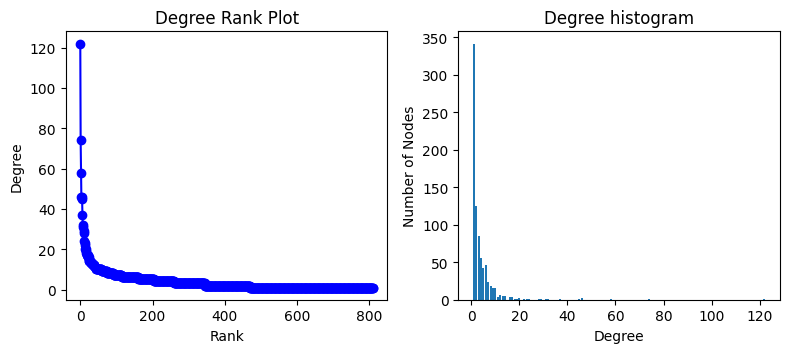

In [165]:
degree_sequence = sorted((d for n, d in G.degree()), reverse=True)
dmax = max(degree_sequence)

fig = plt.figure("Degree of a random graph", figsize=(8, 8))
# Create a gridspec for adding subplots of different sizes
axgrid = fig.add_gridspec(5, 4)

# ax0 = fig.add_subplot(axgrid[0:3, :])
# Gcc = G.subgraph(sorted(nx.connected_components(G), key=len, reverse=True)[0])
# pos = nx.spring_layout(Gcc, seed=10396953)
# nx.draw_networkx_nodes(Gcc, pos, ax=ax0, node_size=20)
# nx.draw_networkx_edges(Gcc, pos, ax=ax0, alpha=0.4)
# # ax0.set_title("Largest connected component of G")
# ax0.set_axis_off()

ax1 = fig.add_subplot(axgrid[3:, :2])
ax1.plot(degree_sequence, "b-", marker="o")
ax1.set_title("Degree Rank Plot")
ax1.set_ylabel("Degree")
ax1.set_xlabel("Rank")

ax2 = fig.add_subplot(axgrid[3:, 2:])
ax2.bar(*np.unique(degree_sequence, return_counts=True))
ax2.set_title("Degree histogram")
ax2.set_xlabel("Degree")
ax2.set_ylabel("Number of Nodes")

fig.tight_layout()
plt.show()

# Profil data understanding

In [166]:
# We use pandas dataframes to load attributes
# Nodes are characterized by a list of colleges, a list of employers, a list of location
# The order means nothing. Nothing allow us to determine the current employer...
df_l = pd.read_csv('location_with_60percent_of_nodes_remoded.csv', sep='\t', header='infer')
type(df_l["location"].loc[0])

str

In [167]:
df_l.groupby('name').count().describe()

,location
count,336.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


In [168]:
df_l['location'].value_counts()

location
urbana-champaign illinois area    92
greater chicago area              33
san francisco bay area            24
greater boston area               16
greater new york city area        16
                                  ..
gainesville florida area           1
edmonton canada area               1
london united kingdom              1
lubbock texas area                 1
kuala lumpur malaysia              1
Name: count, Length: 89, dtype: int64

Test here the homophily in the graph for each attribute


In [169]:
college = pd.read_csv('college_with_60percent_of_nodes_remoded.csv', sep='\t', header='infer')

In [170]:
college.groupby('name').count()

,college
name,
U10051,1
U1045,3
U1055,1
U1068,2
U1104,1
...,...
U9667,1
U9680,1
U9689,1


## Model

Strategies to fill the profiles and compare with the baseline

# Missing localisations

## 1. Predictions

In [171]:
employer = pd.read_csv('./employer_with_60percent_of_nodes_remoded.csv', sep='\t', header='infer')
college = pd.read_csv('./college_with_60percent_of_nodes_remoded.csv', sep='\t', header='infer')

location = pd.read_csv('location_with_60percent_of_nodes_remoded.csv', sep='\t', header='infer')

In [172]:
predicted_values = {}

In [173]:
# Get a list from a Series
filled_nodes_employer = employer['name'].drop_duplicates().tolist()
filled_nodes_college = college['name'].drop_duplicates().tolist()
filled_nodes_location = location['name'].drop_duplicates().tolist()
print(f'{len(filled_nodes_employer)*100/G.number_of_nodes():.2f} % of nodes have attributes (here employer attribute)')
print(f'{len(filled_nodes_college)*100/G.number_of_nodes():.2f} % of nodes have attributes (here college attribute)')
print(f'{len(filled_nodes_location)*100/G.number_of_nodes():.2f} % of nodes have attributes (here location attribute)')

36.62 % of nodes have attributes (here employer attribute)
28.36 % of nodes have attributes (here college attribute)
41.43 % of nodes have attributes (here location attribute)


In [174]:
#list difference, need the function `set()` to create sets ;-)
empty=set(G.nodes())-set(filled_nodes_location)
print(f'{len(empty)} empty nodes, without any location attributes')

475 empty nodes, without any location attributes


In [175]:
def fill_location(graph, df_e, df_c, df_l, cycle, coef_sf, score_r, score_co, score_cl, coef_1_2):
    """   Predict the missing attribute with a simple but effective
    relational classifier. 
    
    The assumption is that two connected nodes are 
    likely to share the same attribute value. Here we chose the most frequently
    used attribute by the neighbors
    
    Parameters
    ----------
    graph : graph
       A networkx graph
    empty : list
       The nodes with empty location attributes 
    df_e : pandas dataframe employer
    df_c : pandas dataframe college
    df_l : pandas dataframe location
    cycle : bool, do we evalue cycles ?
    coef_sf : coefficient for san francisco baie
    score_r, score_co, score_cl : score of relation, colleague, classmate
    coef_1_2 : coefficient between voisins_1 and voisins_2 to calculate the score

    Returns
    -------
    predicted_values : dict 
       A dict of attributes, either location, employer or college attributes. 
       key is a node (from empty), value is a list of attribute values. Here 
       only 1 value in the list.
     """

    df_l = df_l.copy() # si memory==True, c'est nécessaire
    predicted_location={}

    filled_nodes = df_l['name'].drop_duplicates().tolist()
    empty = set(graph.nodes())-set(filled_nodes)

    for n in empty: 
        score_locations_n = {} # {location:int(score/3) ...}
        
        # sélection des voisins au 1er et 2eme degré
        voisins_1 = set(graph.neighbors(n))
        voisins_2 = set()
        for v in voisins_1:
            voisins_2.update(graph.neighbors(v))
        voisins_2 -= voisins_1 | {n}  # on enlève les voisins au 1er degré potentiellement trouvés (cycle ou retour en arrière)
        

        relations_with_loc = (voisins_1 | voisins_2) - empty
        total_relations = len(relations_with_loc)
        
        # On regarde les voisins directes, si il existe des voisins avec un localisation
        if total_relations != 0: 

            ######## variables utiles colleagues: ########
            employers_n = df_e.loc[df_e.name == n ,'employer'].values
            #recherche de tous les collègues : ils sont en relation directe avec une location et ont déjà eu le même employer
            colleagues = df_e.loc[df_e.name.isin(relations_with_loc) & df_e.employer.isin(employers_n) ,'name'].unique()
            # .unique() sinon colleagues peut contenir 2 fois le même voisin (pk ils ont pu avoir 2 fois 2 employers similaires)
            total_colleagues = len(colleagues)

            ######## variables utiles classmates: ########
            colleges_n = df_c.loc[df_c.name == n ,'college'].values
            #recherche de tous les collègues : ils sont en relation directe avec une location et ont déjà eu le même employer
            classmates = df_c.loc[df_c.name.isin(relations_with_loc) & df_c.college.isin(colleges_n) ,'name'].unique()
            # .unique() sinon colleagues peut contenir 2 fois le même voisin (pk ils ont pu avoir 2 fois 2 employers similaires)
            total_classmates = len(classmates)

            for node in relations_with_loc:
                location_node = df_l.loc[df_l.name == node ,'location'].values[0]
                ######## relations: ########
                # on considère toutes les relations
                if location_node not in score_locations_n:
                    score_locations_n[location_node] = 0
                if node in voisins_1: # voisin au premier degré ont plus de poids
                    score_locations_n[location_node] += score_r
                else:
                    score_locations_n[location_node] += coef_1_2*score_r

                ###### colleagues: ########
                # on considère tous les voisins directs avec une localisation travaillant ou ayant travaillé pour la(les) même(s) employé(s)
                if (total_colleagues!=0) and (node in colleagues):
                    if node in voisins_1: # voisin au premier degré ont plus de poids
                        score_locations_n[location_node] += score_co
                        print("collègue voisin 1")
                    else:
                        score_locations_n[location_node] += coef_1_2*score_co
                        print("collègue voisin 2")
                        

                ######## classmates: ########
                # on considère tous les voisins directs avec une localisation ayant déjà étudié dans une des universités du noeud
                if (total_classmates!=0) and (node in classmates):
                    if node in voisins_1: # voisin au premier degré ont plus de poids
                        score_locations_n[location_node] += score_cl
                        print("classmate voisin 1")
                    else:
                        score_locations_n[location_node] += coef_1_2*score_cl
                        print("classmate voisin 2")

                ######## SF Baie: ########
                if location_node=="san francisco bay area":
                    score_locations_n[location_node] += coef_sf
        
        #### étude des cycles incluant le noeud n puis donner un poids à chaque localisation dans chaque cycle
        if cycle:
            # 1. Réduire le graphe aux seuls noeuds pertinents
            depuis = nx.descendants(graph, n) | {n}
            vers   = nx.ancestors(graph, n)   | {n}
            sous_graphe = graph.subgraph(depuis & vers)
            cycles_avec_n = [c for c in nx.simple_cycles(sous_graphe, length_bound=5) if n in c and len(c) == 5]
            for cycle in cycles_avec_n:
                for n_cycle in cycle:
                    if n_cycle != n and n_cycle in df_l["name"]:
                        location_n_cycle = df_l.loc[df_l.name == n_cycle ,'location'].values[0]
                        score_locations_n[location_n_cycle] += 3 ### score pertinent ????


        
        if len(score_locations_n)!=0:
            predicted_location[n] = max(score_locations_n, key=score_locations_n.get)
            if predicted_location[n] != "san francisco bay area":
                predicted_location[n] = "other"

        if total_relations == 0 :
            predicted_location[n] = "NotFound"



    return predicted_location


## 2. Evaluation: Définition des métriques

In [176]:
df_l_truth = pd.read_csv('./groundtruth/location.csv', sep='\t', header='infer')

In [177]:
def evaluation_accuracy(groundtruth, pred):
    """    Compute the accuracy of your model.

     The accuracy is the proportion of true results.

    Parameters
    ----------
    groundtruth : pandas dataframe 
       Either location, employer or college dataframe. 
    pred : dict 
       A dict of attributes, either location, employer or college attributes. 
       key is a node, value is a list of attribute values. 

    Returns
    -------
    out : float
       Accuracy.
    """
    true_positive_prediction=0
    predicted=0
    for p_key, p_value in pred.items():
        true_loc = groundtruth.loc[groundtruth.name == p_key , 'location'].values[0]
        if true_loc == "san francisco bay area" and p_value == true_loc:
            true_positive_prediction+=1

        if p_value == "other" and true_loc != "san francisco bay area" : # inclue p_value=="NotFound" 
            true_positive_prediction+=1

        predicted+=1
    return true_positive_prediction*100/predicted

In [178]:
def evaluation_recall(groundtruth, pred):
    """    Compute the recall of your model.

    Parameters
    ----------
    groundtruth : pandas dataframe 
       Either location, employer or college dataframe. 
    pred : dict 
       A dict of attributes, either location, employer or college attributes. 
       key is a node, value is a list of attribute values. 

    Returns
    -------
    out : float
       Accuracy.
    """
    true_positive_prediction=0 # Baie prédits baies
    predicted=0 # nombre total de Baie dans les données complètes
    for p_key, p_value in pred.items():
        true_loc = groundtruth.loc[groundtruth.name == p_key , 'location'].values[0] # car il n'y a toujours qu'une seule location
        if true_loc == "san francisco bay area":
            predicted+=1
            if p_value == true_loc:
                true_positive_prediction+=1
    return true_positive_prediction*100/predicted

In [179]:
def evaluation_precision(groundtruth, pred):
    """    Compute the precision of your model.


    Parameters
    ----------
    groundtruth : pandas dataframe 
       Either location, employer or college dataframe. 
    pred : dict 
       A dict of attributes, either location, employer or college attributes. 
       key is a node, value is a list of attribute values. 

    Returns
    -------
    out : float
       Accuracy.
    """
    true_positive_prediction=0 # Baie bien prédites
    predicted=0 # nombre total de Baie dans les données complètes
    for p_key, p_value in pred.items():
      true_loc = groundtruth.loc[groundtruth.name == p_key , 'location'].values[0] 
      if true_loc == "san francisco bay area" and p_value == true_loc:
         true_positive_prediction+=1
      elif p_value == "san francisco bay area":
         predicted+=1

    return true_positive_prediction*100/predicted

# 3. EVALUATION + RESULTS

## 3.1 Evaluation variation coef_1_2 sans augmentation du poids pour collègue

### a. PREDICTION

In [ ]:
predicted_location = {}

for coef_1_2 in np.arange(0, 1.1, 0.1):
    predicted_location[f"{coef_1_2}"] = fill_location(G, employer, college, location, False, 0.1, 1, 100, 1, round(coef_1_2, 1))
print(len(predicted_location))

11


### b. EVALUATION

In [ ]:
result_ac = []
ordre_ac = []
print(len(predicted_location))
for param in predicted_location:
    result_ac.append(evaluation_accuracy(df_l_truth, predicted_location[param]))
    ordre_ac.append(param)
print(result_ac)
print(ordre_ac)
result_rec = []
ordre_rec = []
for param in predicted_location:
    result_rec.append(evaluation_recall(df_l_truth, predicted_location[param]))
    ordre_rec.append(param)

print(result_rec)
print(ordre_rec)
result_prec = []
ordre_prec = []

for param in predicted_location:
    if param != "score_r,score_co,score_cl,coef_1_2":
        result_prec.append(evaluation_precision(df_l_truth, predicted_location[param]))
        ordre_prec.append(param)
print(result_prec)
print(ordre_prec)


11
[65.6842105263158, 77.89473684210526, 85.47368421052632, 85.89473684210526, 86.73684210526316, 86.73684210526316, 86.52631578947368, 86.3157894736842, 86.10526315789474, 86.10526315789474, 85.89473684210526]
['0.0', '0.1', '0.2', '0.30000000000000004', '0.4', '0.5', '0.6000000000000001', '0.7000000000000001', '0.8', '0.9', '1.0']
[63.63636363636363, 30.90909090909091, 14.545454545454545, 14.545454545454545, 9.090909090909092, 9.090909090909092, 7.2727272727272725, 5.454545454545454, 5.454545454545454, 5.454545454545454, 5.454545454545454]
['0.0', '0.1', '0.2', '0.30000000000000004', '0.4', '0.5', '0.6000000000000001', '0.7000000000000001', '0.8', '0.9', '1.0']
[25.0, 26.5625, 42.10526315789474, 47.05882352941177, 50.0, 50.0, 40.0, 30.0, 27.272727272727273, 27.272727272727273, 25.0]
['0.0', '0.1', '0.2', '0.30000000000000004', '0.4', '0.5', '0.6000000000000001', '0.7000000000000001', '0.8', '0.9', '1.0']


### c. AFFICHAGE

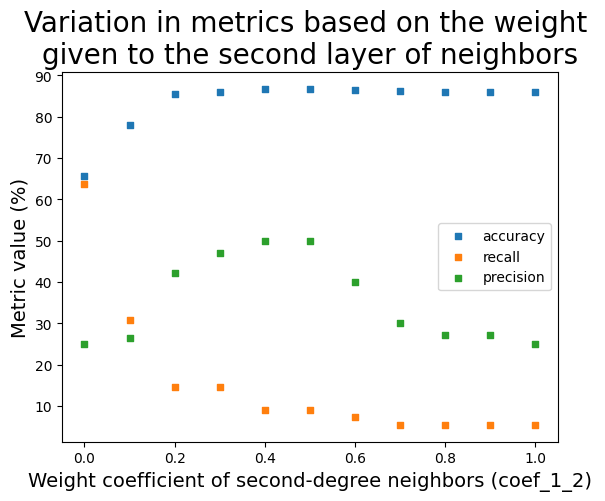

In [ ]:
x = np.arange(0, 1.1, 0.1)
plt.figure()

plt.scatter(x,result_ac, label="accuracy", marker = "s",s = 20)
plt.scatter(x,result_rec, label="recall", marker = "s",s = 20)
plt.scatter(x,result_prec, label="precision", marker = "s",s = 20)
plt.xlabel("Weight coefficient of second-degree neighbors (coef_1_2)",fontsize = 14)
plt.ylabel("Metric value (%)", fontsize = 14)
plt.title("Variation in metrics based on the weight \ngiven to the second layer of neighbors", fontsize = 20)
plt.legend()
plt.show()

## 3.7 Result Grid

On conserve, d'après les parties précédentes: score_r=score_co=score_cl=1 ,coef_1_2 = 0.1 et coef_sf = 0.2

In [ ]:
predicted_location = {}

coef_1_2_values = np.arange(0, 1.1, 0.1)
x1 = np.arange(0, 0.1, 0.02)
x2 = np.arange(0.1, 1, 0.1)
x = np.concatenate([x1, x2])

### a. CALCUL DES PRÉDICTIONS
for coef_1_2 in tqdm(coef_1_2_values):
    predicted_location[f"{coef_1_2:.1f}"] = {}
    for coef_sf in tqdm(x1):
        predicted_location[f"{coef_1_2:.1f}"][f"{coef_sf}"] = fill_location(G, employer, college, location, False, coef_sf, 1, 1, 1, coef_1_2)
    for coef_sf in tqdm(x2):
        predicted_location[f"{coef_1_2:.1f}"][f"{coef_sf}"] = fill_location(G, employer, college, location, False, coef_sf, 1, 1, 1, coef_1_2)

print(f"Nombre de combinaisons coef_1_2 : {len(predicted_location)}")

### b. ÉVALUATION
results = {}  # results[coef_1_2] = {"ac": [], "rec": [], "prec": []}

for coef_1_2_key, preds_by_sf in predicted_location.items():
    ac_list, rec_list, prec_list = [], [], []
    for coef_sf_key, pred in preds_by_sf.items():
        ac_list.append(evaluation_accuracy(df_l_truth, pred))
        rec_list.append(evaluation_recall(df_l_truth, pred))
        prec_list.append(evaluation_precision(df_l_truth, pred))
    results[coef_1_2_key] = {"ac": ac_list, "rec": rec_list, "prec": prec_list}

### c. AFFICHAGE 

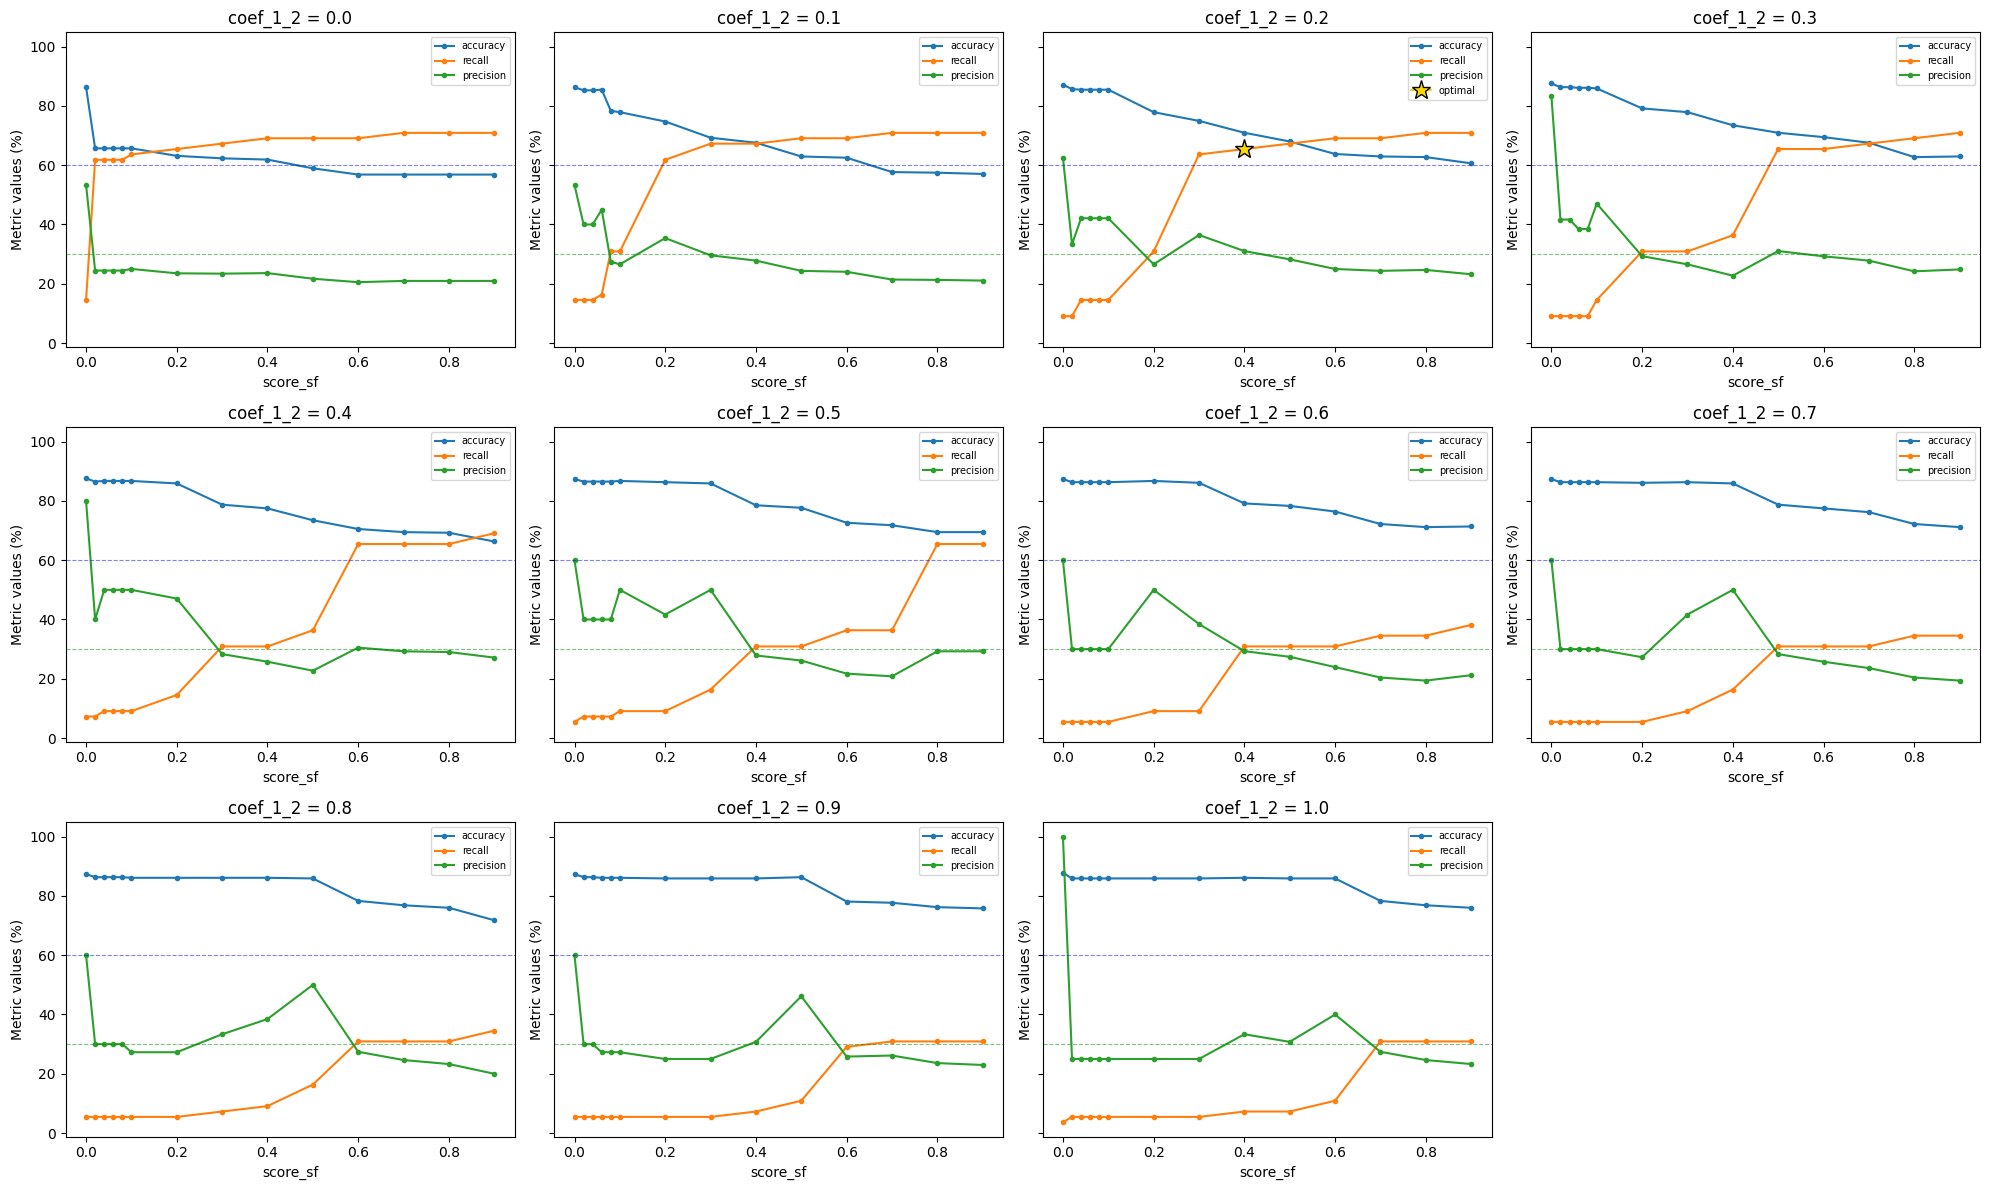

In [ ]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4), sharey=True)
axes = axes.flatten()

best_coef_1_2_key, best_coef_sf, _, best_rec, _ = best_params[0]

for i, coef_1_2_key in enumerate(results):
    ax = axes[i]
    ax.plot(x, results[coef_1_2_key]["ac"],   marker="o", markersize=3, label="accuracy")
    ax.plot(x, results[coef_1_2_key]["rec"],  marker="o", markersize=3, label="recall")
    ax.plot(x, results[coef_1_2_key]["prec"], marker="o", markersize=3, label="precision")

    if coef_1_2_key == best_coef_1_2_key:
        idx_opt = np.argmin(np.abs(x - best_coef_sf))
        ax.plot(best_coef_sf, best_rec,
                marker="*", markersize=14, color="gold",
                markeredgecolor="black", zorder=5, label="optimal")

    ax.axhline(60, color="blue",  linestyle="--", linewidth=0.8, alpha=0.5)
    ax.axhline(30, color="green", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.set_title(f"coef_1_2 = {coef_1_2_key}", fontsize=12)
    ax.set_xlabel("score_sf", fontsize=10)
    ax.set_ylabel("Metric values (%)", fontsize=10)
    ax.legend(fontsize=7)

for j in range(len(results), len(axes)):
    axes[j].set_visible(False)

# fig.suptitle("Search for the most optimized parameters coef_1_2 and score_sf", fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

In [139]:
### e. AFFICHAGE DES RÉSULTATS
if best_params:
    coef_1_2_key, coef_sf, ac, rec, prec = best_params[0]
    print(f"{'='*50}")
    print(f"  Meilleur point trouvé")
    print(f"{'='*50}")
    print(f"  coef_1_2  = {coef_1_2_key}")
    print(f"  score_sf  = {coef_sf:.4f}")
    print(f"{'-'*50}")
    print(f"  Accuracy  : {ac:.2f}%   (contrainte : > 60%)")
    print(f"  Recall    : {rec:.2f}%  ← maximisé")
    print(f"  Precision : {prec:.2f}%  (contrainte : > 30%)")
    print(f"{'='*50}")
else:
    print("Aucun point ne satisfait les contraintes.")



  Meilleur point trouvé
  coef_1_2  = 0.2
  score_sf  = 0.4000
--------------------------------------------------
  Accuracy  : 70.95%   (contrainte : > 60%)
  Recall    : 65.45%  ← maximisé
  Precision : 31.03%  (contrainte : > 30%)
